In [1]:
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

print("pandas:", pd.__version__)
print("sklearn:", sklearn.__version__)
print("All libraries loaded successfully!")

Matplotlib is building the font cache; this may take a moment.


pandas: 3.0.3
sklearn: 1.9.0
All libraries loaded successfully!


In [2]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 500

df = pd.DataFrame({
    'customer_id': range(1, n+1),
    'age': np.random.randint(18, 70, n),
    'annual_income': np.random.randint(20000, 120000, n),
    'purchase_frequency': np.random.randint(1, 20, n),
    'avg_order_value': np.random.randint(20, 500, n),
    'days_since_last_purchase': np.random.randint(1, 365, n)
})

print(df.shape)
df.head()

(500, 6)


,customer_id,age,annual_income,purchase_frequency,avg_order_value,days_since_last_purchase
0,1,56,23343,17,459,356
1,2,69,33500,13,255,173
2,3,46,73222,4,258,221
3,4,32,49375,10,396,119
4,5,60,29662,3,285,309


In [3]:
# Check basic info
print("Dataset shape:", df.shape)
print("\nColumn types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nBasic statistics:")
df.describe()

Dataset shape: (500, 6)

Column types:
customer_id                 int64
age                         int32
annual_income               int32
purchase_frequency          int32
avg_order_value             int32
days_since_last_purchase    int32
dtype: object

Missing values:
customer_id                 0
age                         0
annual_income               0
purchase_frequency          0
avg_order_value             0
days_since_last_purchase    0
dtype: int64

Basic statistics:


,customer_id,age,annual_income,purchase_frequency,avg_order_value,days_since_last_purchase
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,44.220000,68167.952000,9.784000,261.724000,188.976000
std,144.481833,15.036082,28693.088647,5.547512,143.630314,105.051755
min,1.000000,18.000000,20055.000000,1.000000,21.000000,1.000000
25%,125.750000,32.000000,43369.750000,5.000000,134.750000,105.750000
50%,250.500000,45.000000,66636.000000,10.000000,260.500000,179.500000
75%,375.250000,57.000000,92395.250000,15.000000,392.250000,287.250000
max,500.000000,69.000000,119835.000000,19.000000,497.000000,364.000000


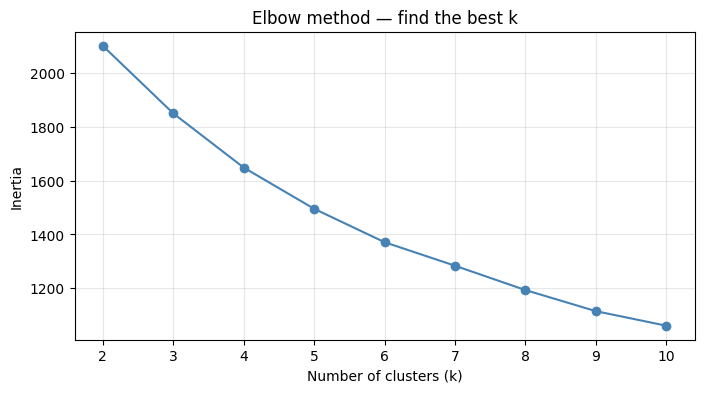

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Select features for clustering
features = ['age', 'annual_income', 'purchase_frequency', 
            'avg_order_value', 'days_since_last_purchase']

X = df[features]

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method
inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# Plot elbow curve
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, marker='o', color='steelblue')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow method — find the best k')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
from sklearn.metrics import silhouette_score

# Fit KMeans with k=4
km = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(X_scaled)

# Check silhouette score (closer to 1.0 = better)
score = silhouette_score(X_scaled, df['cluster'])
print(f"Silhouette score: {score:.3f}")

# See the average of each feature per cluster
print("\nCluster profiles:")
print(df.groupby('cluster')[features].mean().round(1))

Silhouette score: 0.160

Cluster profiles:
          age  annual_income  purchase_frequency  avg_order_value  \
cluster                                                             
0        54.9        71342.2                12.2            270.4   
1        52.7        70224.6                 5.5            348.8   
2        38.2        66988.5                14.6            217.4   
3        30.4        63833.4                 6.0            214.7   

         days_since_last_purchase  
cluster                            
0                            92.5  
1                           269.2  
2                           270.9  
3                           128.1  


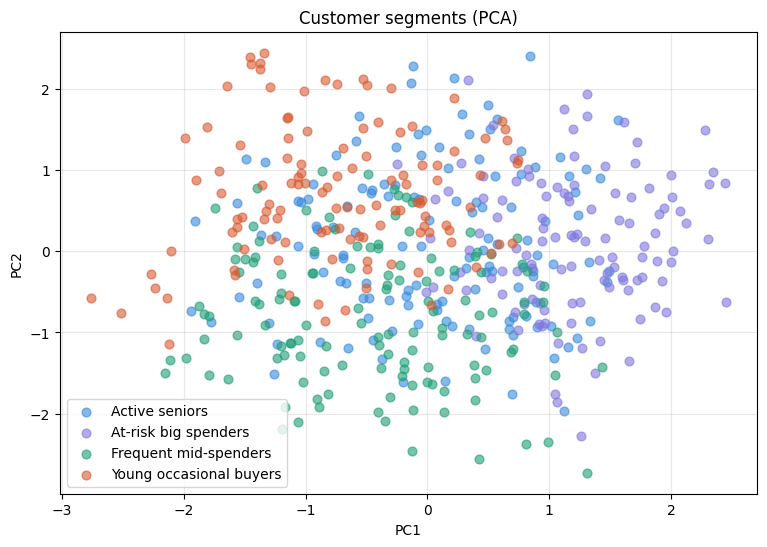

In [6]:
# Label the segments
labels = {
    0: 'Active seniors',
    1: 'At-risk big spenders',
    2: 'Frequent mid-spenders',
    3: 'Young occasional buyers'
}
df['segment'] = df['cluster'].map(labels)

# Visualize using PCA
from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
df['pc1'] = coords[:, 0]
df['pc2'] = coords[:, 1]

plt.figure(figsize=(9, 6))
colors = {
    'Active seniors': '#378ADD',
    'At-risk big spenders': '#7F77DD',
    'Frequent mid-spenders': '#1D9E75',
    'Young occasional buyers': '#D85A30'
}
for seg, grp in df.groupby('segment'):
    plt.scatter(grp['pc1'], grp['pc2'], 
                label=seg, alpha=0.6, s=40,
                color=colors[seg])

plt.legend()
plt.title('Customer segments (PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True, alpha=0.3)
plt.show()

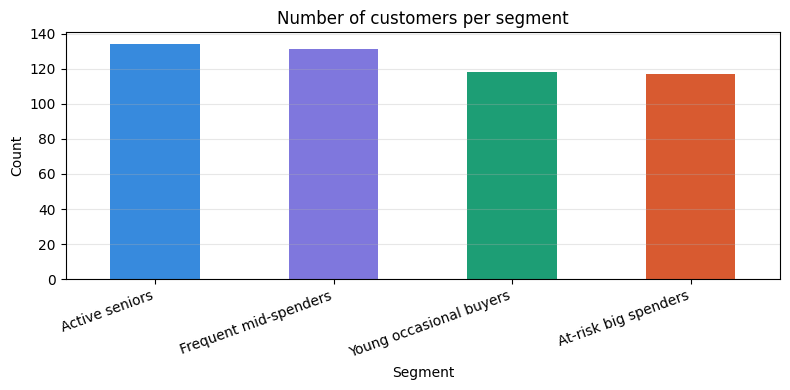

Saved! Columns: ['customer_id', 'age', 'annual_income', 'purchase_frequency', 'avg_order_value', 'days_since_last_purchase', 'cluster', 'segment', 'pc1', 'pc2']

Segment counts:


NameError: name 'pr' is not defined

In [7]:
# Segment size bar chart
plt.figure(figsize=(8, 4))
counts = df['segment'].value_counts()
colors_list = ['#378ADD', '#7F77DD', '#1D9E75', '#D85A30']
counts.plot(kind='bar', color=colors_list, edgecolor='none')
plt.title('Number of customers per segment')
plt.xlabel('Segment')
plt.ylabel('Count')
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Export results to CSV
df.to_csv('segmented_customers.csv', index=False)
print("Saved! Columns:", list(df.columns))
print("\nSegment counts:")
pr

In [8]:
print(df['segment'].value_counts())

segment
Active seniors             134
Frequent mid-spenders      131
Young occasional buyers    118
At-risk big spenders       117
Name: count, dtype: int64
